# Industrial Defect Detection Pipeline

This lab notebook follows the exact pipeline shown in the industrial defect example:

**Original Image → Grayscale → Contrast Enhancement → Denoising → Edge Detection → Thresholding → Defect Mask → Final Highlighted Defect**

The aim is to detect visible industrial surface defects such as:

- cracks
- holes
- scratches
- dark surface defects
- abnormal damaged regions

This notebook uses classical image processing techniques with **OpenCV**, **NumPy**, and **Matplotlib**.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Install and import required libraries

Run the installation cell only if the libraries are not already available in your environment.


In [ ]:
# Optional installation
# Uncomment and run this line if OpenCV is not installed:
# !pip install opencv-python numpy matplotlib

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["image.cmap"] = "gray"


## 2. Load the original industrial defect image

Place the image file in the same folder as this notebook.

For this lab, the expected image name is:

```text
industrial_defect_sample.png
```

You can replace it with another industrial defect image later.


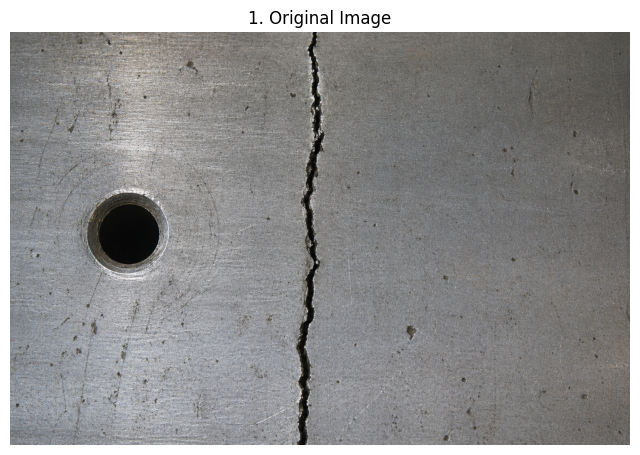

In [5]:
# Image path
image_path = Path("/content/drive/MyDrive/Recent Codes/Industrial metal texture with crack and hole.png")

# Load image in BGR format using OpenCV
img_bgr = cv2.imread(str(image_path))


# Convert BGR to RGB for correct display with Matplotlib
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("1. Original Image")
plt.axis("off")
plt.show()


## 3. Convert to grayscale

Grayscale conversion simplifies the image by removing colour information.  
This is useful because many defect detection tasks depend mainly on intensity differences rather than colour.


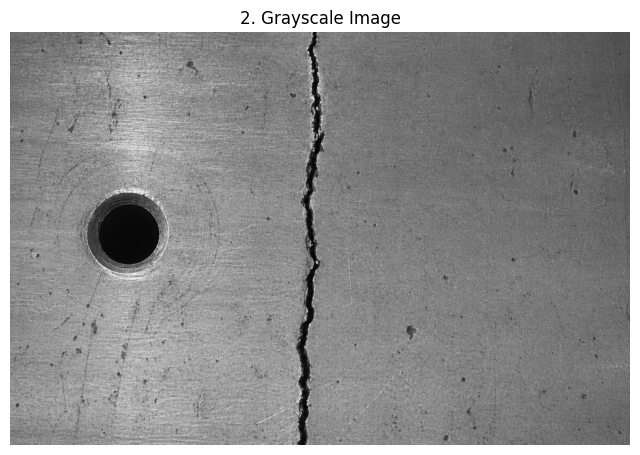

In [6]:
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap="gray")
plt.title("2. Grayscale Image")
plt.axis("off")
plt.show()


## 4. Contrast enhancement using CLAHE

Industrial images often have uneven illumination and low contrast.  
CLAHE improves local contrast and makes cracks or defects more visible.

CLAHE means:

**Contrast Limited Adaptive Histogram Equalization**


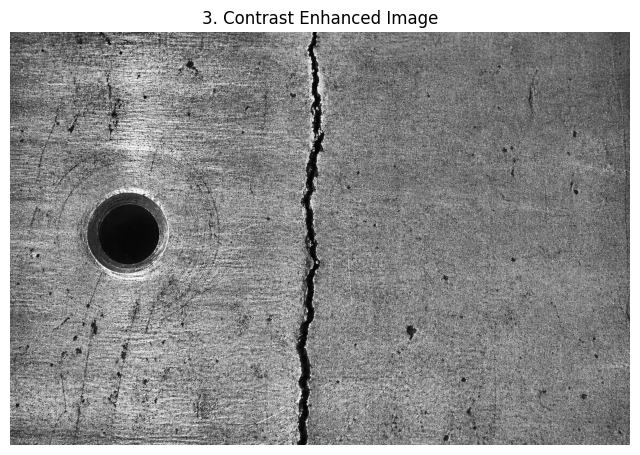

In [7]:
clahe = cv2.createCLAHE(
    clipLimit=2.5,
    tileGridSize=(8, 8)
)

contrast_enhanced = clahe.apply(gray)

plt.imshow(contrast_enhanced, cmap="gray")
plt.title("3. Contrast Enhanced Image")
plt.axis("off")
plt.show()


## 5. Denoising

Denoising reduces small random texture and surface noise while keeping important structures such as cracks and holes.

A Gaussian blur is used here.


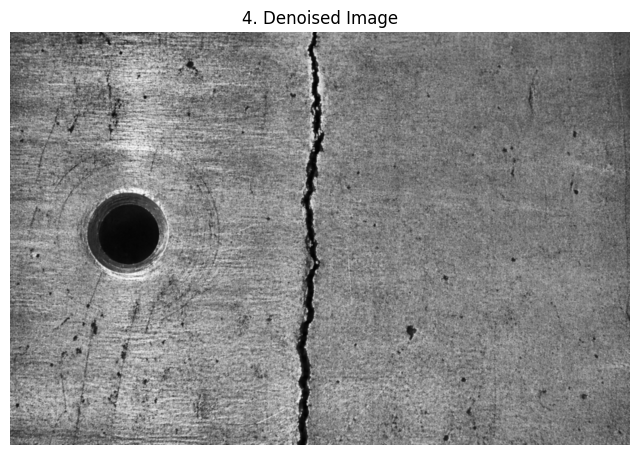

In [8]:
denoised = cv2.GaussianBlur(
    contrast_enhanced,
    ksize=(5, 5),
    sigmaX=0
)

plt.imshow(denoised, cmap="gray")
plt.title("4. Denoised Image")
plt.axis("off")
plt.show()


## 6. Edge detection using Canny

Canny edge detection highlights sharp changes in intensity.  
This is useful for detecting crack boundaries, hole boundaries, scratches, and object edges.


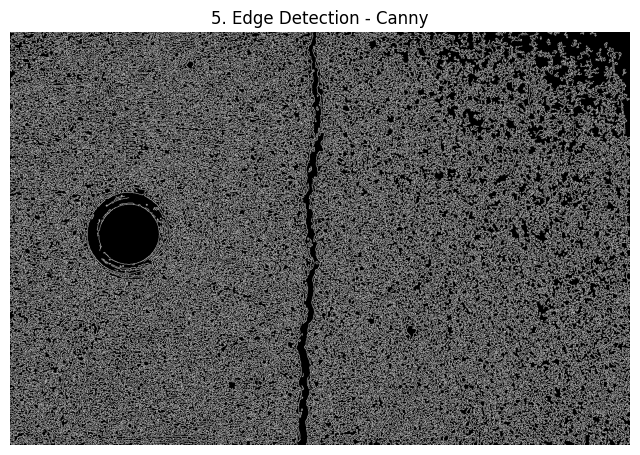

In [9]:
edges = cv2.Canny(
    denoised,
    threshold1=50,
    threshold2=150
)

plt.imshow(edges, cmap="gray")
plt.title("5. Edge Detection - Canny")
plt.axis("off")
plt.show()


## 7. Thresholding

Thresholding separates dark defect regions from the brighter metal background.

In this example, dark cracks and holes are selected using inverse thresholding.


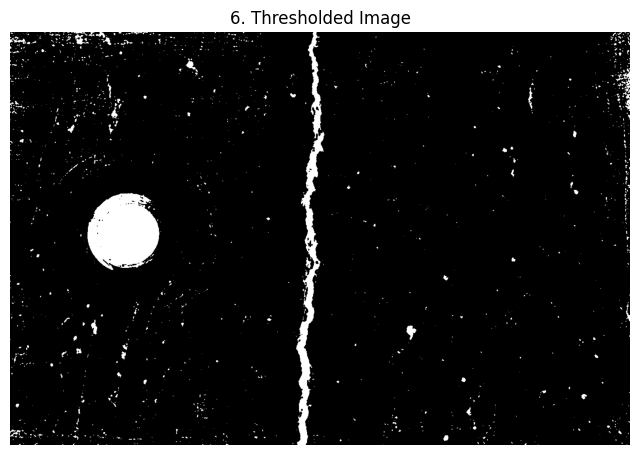

In [10]:
# Inverse threshold: dark regions become white
_, thresholded = cv2.threshold(
    denoised,
    70,
    255,
    cv2.THRESH_BINARY_INV
)

plt.imshow(thresholded, cmap="gray")
plt.title("6. Thresholded Image")
plt.axis("off")
plt.show()


## 8. Create a cleaner defect mask

Morphological operations clean the binary mask.

We use:

- **Opening** to remove small noise
- **Closing** to connect broken parts of defects
- **Dilation** to make crack regions easier to visualize


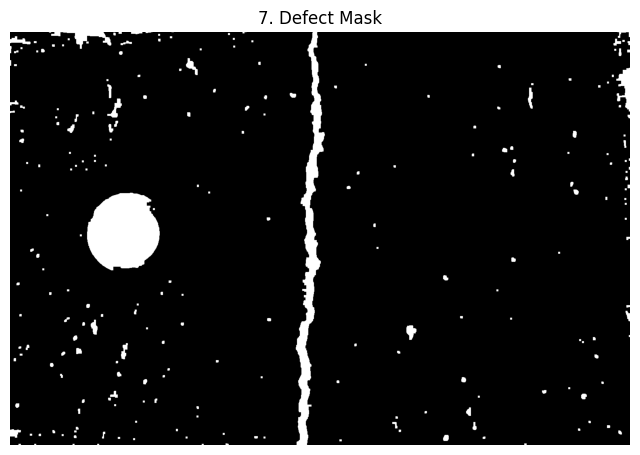

In [11]:
kernel_small = np.ones((3, 3), np.uint8)
kernel_medium = np.ones((5, 5), np.uint8)

mask_open = cv2.morphologyEx(
    thresholded,
    cv2.MORPH_OPEN,
    kernel_small,
    iterations=1
)

mask_close = cv2.morphologyEx(
    mask_open,
    cv2.MORPH_CLOSE,
    kernel_medium,
    iterations=2
)

defect_mask = cv2.dilate(
    mask_close,
    kernel_small,
    iterations=1
)

plt.imshow(defect_mask, cmap="gray")
plt.title("7. Defect Mask")
plt.axis("off")
plt.show()


## 9. Find defect contours

Contours allow us to measure and highlight detected defect regions.

Very small regions are ignored because they are usually noise.


In [12]:
contours, _ = cv2.findContours(
    defect_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

min_area = 300
defect_contours = []

for cnt in contours:
    area = cv2.contourArea(cnt)
    if area >= min_area:
        defect_contours.append(cnt)

print(f"Total contours found: {len(contours)}")
print(f"Defect contours after area filtering: {len(defect_contours)}")


Total contours found: 239
Defect contours after area filtering: 12


## 10. Final result: highlight detected defects

Detected regions are shown on the original image.

The code draws:

- red contour lines around defects
- bounding boxes
- labels
- defect measurements


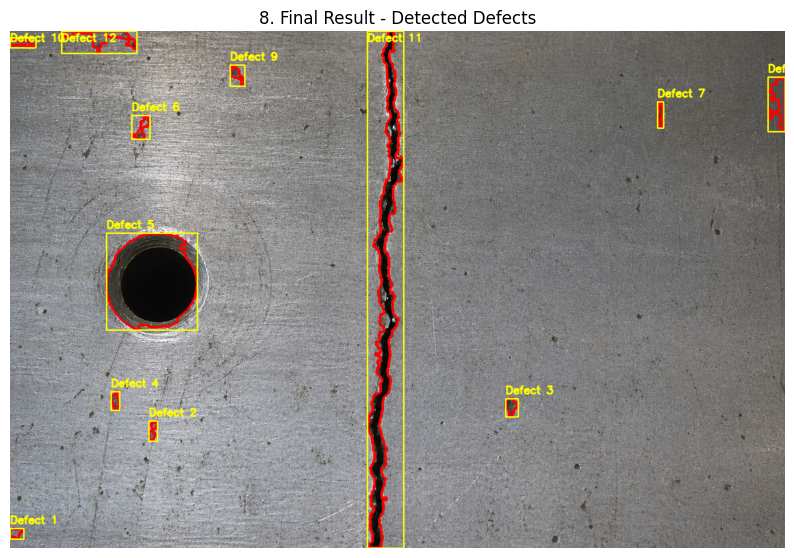

[{'Defect_ID': 1,
  'Area_pixels': 346.0,
  'Perimeter_pixels': 89.31,
  'Bounding_box': (0, 985, 27, 21)},
 {'Defect_ID': 2,
  'Area_pixels': 324.5,
  'Perimeter_pixels': 111.21,
  'Bounding_box': (275, 772, 17, 40)},
 {'Defect_ID': 3,
  'Area_pixels': 532.0,
  'Perimeter_pixels': 105.11,
  'Bounding_box': (982, 728, 25, 36)},
 {'Defect_ID': 4,
  'Area_pixels': 350.5,
  'Perimeter_pixels': 94.04,
  'Bounding_box': (200, 714, 17, 37)},
 {'Defect_ID': 5,
  'Area_pixels': 26313.5,
  'Perimeter_pixels': 662.94,
  'Bounding_box': (191, 400, 180, 192)},
 {'Defect_ID': 6,
  'Area_pixels': 551.5,
  'Perimeter_pixels': 156.53,
  'Bounding_box': (241, 167, 36, 47)},
 {'Defect_ID': 7,
  'Area_pixels': 340.5,
  'Perimeter_pixels': 122.04,
  'Bounding_box': (1283, 140, 12, 52)},
 {'Defect_ID': 8,
  'Area_pixels': 1734.0,
  'Perimeter_pixels': 359.25,
  'Bounding_box': (1502, 91, 34, 108)},
 {'Defect_ID': 9,
  'Area_pixels': 442.0,
  'Perimeter_pixels': 123.94,
  'Bounding_box': (436, 67, 29, 42)},

In [13]:
final_result = img_rgb.copy()

measurements = []

for i, cnt in enumerate(defect_contours, start=1):
    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)
    x, y, w, h = cv2.boundingRect(cnt)

    measurements.append({
        "Defect_ID": i,
        "Area_pixels": round(area, 2),
        "Perimeter_pixels": round(perimeter, 2),
        "Bounding_box": (x, y, w, h)
    })

    # Draw contour and bounding box
    cv2.drawContours(final_result, [cnt], -1, (255, 0, 0), 3)
    cv2.rectangle(final_result, (x, y), (x + w, y + h), (255, 255, 0), 2)

    # Label
    cv2.putText(
        final_result,
        f"Defect {i}",
        (x, max(y - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255, 255, 0),
        2,
        cv2.LINE_AA
    )

plt.figure(figsize=(10, 7))
plt.imshow(final_result)
plt.title("8. Final Result - Detected Defects")
plt.axis("off")
plt.show()

measurements


## 11. Show the full pipeline in one figure

This summary figure should look similar to the pipeline visual:

1. Original image  
2. Grayscale image  
3. Contrast enhanced image  
4. Denoised image  
5. Canny edge detection  
6. Thresholded image  
7. Defect mask  
8. Final detected defect image  


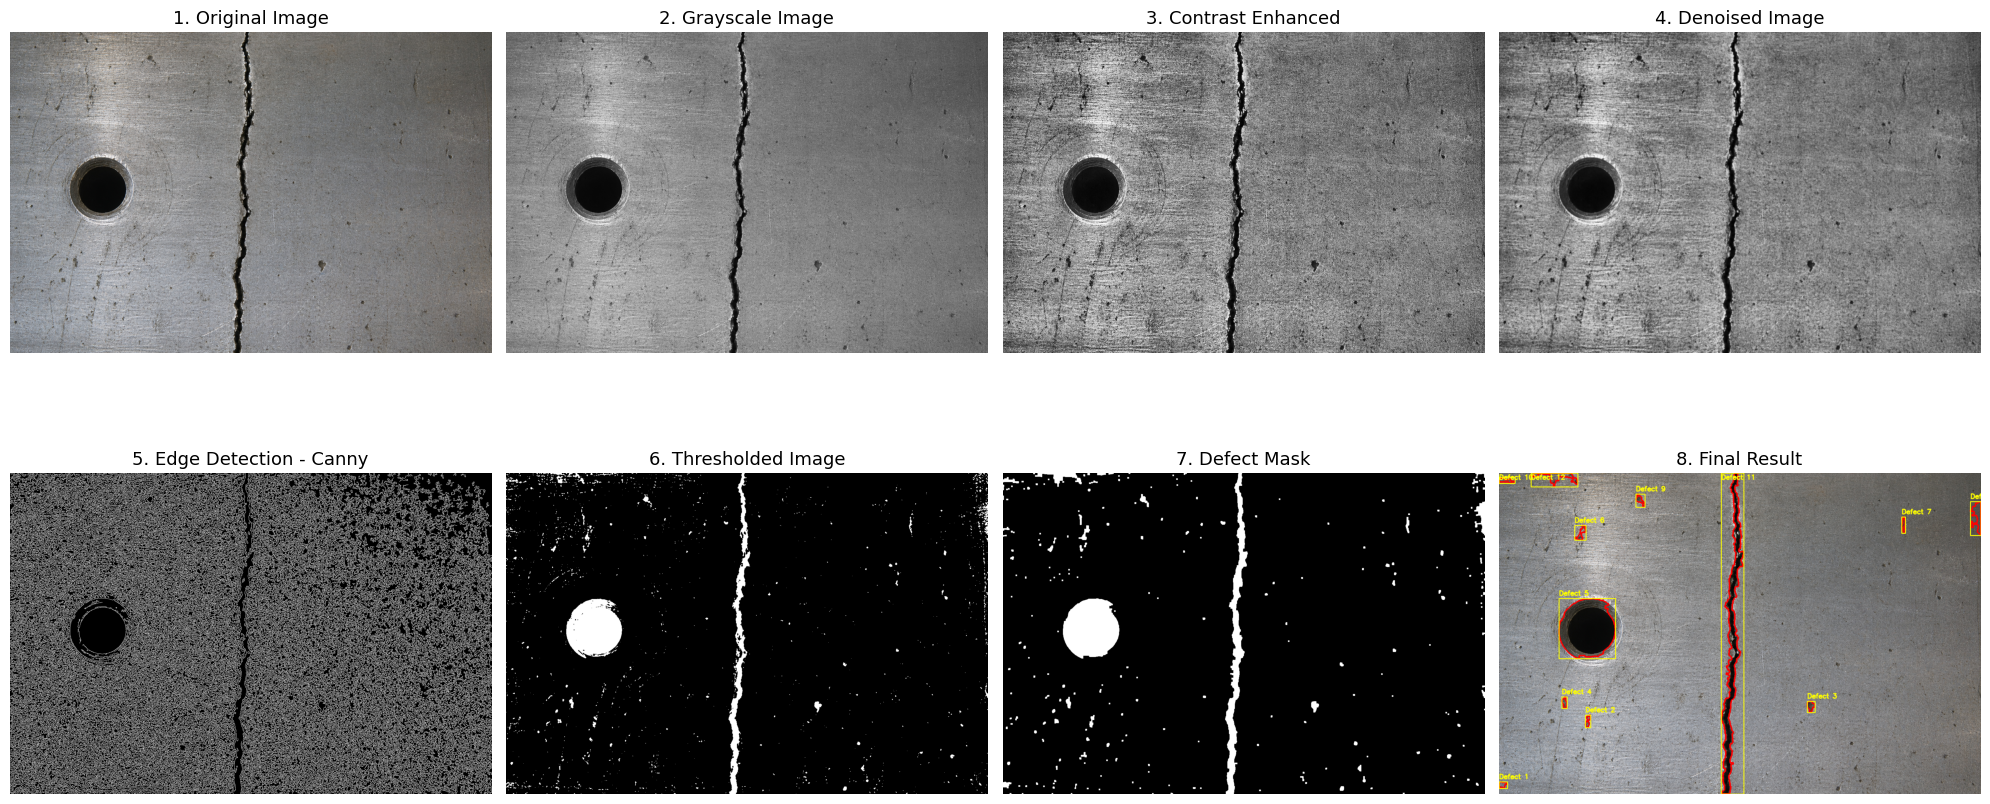

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

images = [
    img_rgb,
    gray,
    contrast_enhanced,
    denoised,
    edges,
    thresholded,
    defect_mask,
    final_result
]

titles = [
    "1. Original Image",
    "2. Grayscale Image",
    "3. Contrast Enhanced",
    "4. Denoised Image",
    "5. Edge Detection - Canny",
    "6. Thresholded Image",
    "7. Defect Mask",
    "8. Final Result"
]

for ax, image, title in zip(axes.ravel(), images, titles):
    if len(image.shape) == 2:
        ax.imshow(image, cmap="gray")
    else:
        ax.imshow(image)

    ax.set_title(title, fontsize=13)
    ax.axis("off")

plt.tight_layout()
plt.show()


## 12. Student task

Try to improve the defect detection result.

Change the following parameters and observe the output:

### Task A: Threshold tuning

Try different threshold values:

```python
50, 60, 70, 80, 90, 100
```

Question:

> Which value detects the crack most clearly?

---

### Task B: Canny tuning

Try different Canny thresholds:

```python
(30, 100)
(50, 150)
(80, 200)
```

Question:

> Which setting gives the cleanest defect edges?

---

### Task C: Morphology tuning

Try changing:

- kernel size
- opening iterations
- closing iterations
- dilation iterations

Question:

> How do morphology operations change the final defect mask?


## 13. Optional extension

Students can add advanced steps:

### Extension 1: Separate crack from circular hole

Use shape features:

- aspect ratio
- contour area
- circularity

Circularity formula:

```text
circularity = 4π × area / perimeter²
```

A circular hole usually has high circularity.  
A long crack usually has low circularity.


Defect 1: area=346.0, perimeter=89.3, circularity=0.545, aspect_ratio=1.286, class=Hole / round defect
Defect 2: area=324.5, perimeter=111.2, circularity=0.330, aspect_ratio=0.425, class=Crack / irregular defect
Defect 3: area=532.0, perimeter=105.1, circularity=0.605, aspect_ratio=0.694, class=Hole / round defect
Defect 4: area=350.5, perimeter=94.0, circularity=0.498, aspect_ratio=0.459, class=Hole / round defect
Defect 5: area=26313.5, perimeter=662.9, circularity=0.752, aspect_ratio=0.938, class=Hole / round defect
Defect 6: area=551.5, perimeter=156.5, circularity=0.283, aspect_ratio=0.766, class=Crack / irregular defect
Defect 7: area=340.5, perimeter=122.0, circularity=0.287, aspect_ratio=0.231, class=Crack / irregular defect
Defect 8: area=1734.0, perimeter=359.3, circularity=0.169, aspect_ratio=0.315, class=Crack / irregular defect
Defect 9: area=442.0, perimeter=123.9, circularity=0.362, aspect_ratio=0.690, class=Crack / irregular defect
Defect 10: area=446.0, perimeter=139.0

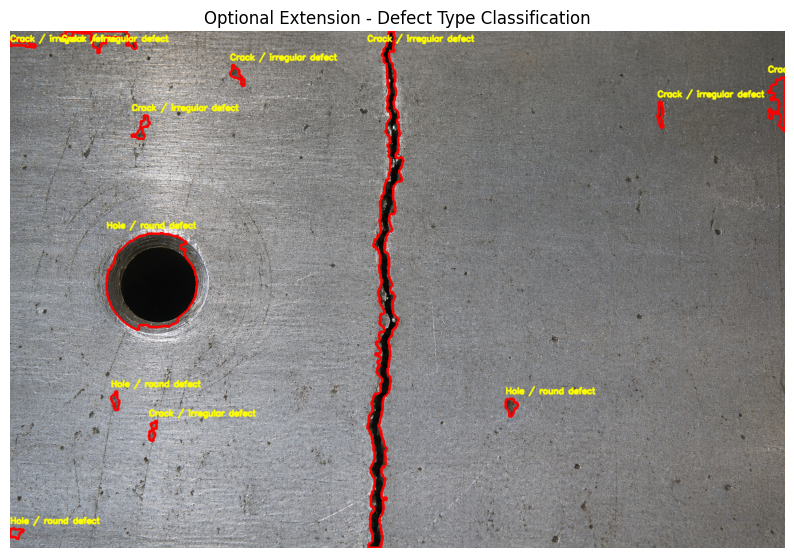

In [15]:
classified_result = img_rgb.copy()

for i, cnt in enumerate(defect_contours, start=1):
    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)

    if perimeter == 0:
        continue

    circularity = (4 * np.pi * area) / (perimeter ** 2)

    x, y, w, h = cv2.boundingRect(cnt)
    aspect_ratio = w / h if h != 0 else 0

    if circularity > 0.45:
        label = "Hole / round defect"
    else:
        label = "Crack / irregular defect"

    cv2.drawContours(classified_result, [cnt], -1, (255, 0, 0), 3)
    cv2.putText(
        classified_result,
        label,
        (x, max(y - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.55,
        (255, 255, 0),
        2,
        cv2.LINE_AA
    )

    print(
        f"Defect {i}: area={area:.1f}, perimeter={perimeter:.1f}, "
        f"circularity={circularity:.3f}, aspect_ratio={aspect_ratio:.3f}, class={label}"
    )

plt.figure(figsize=(10, 7))
plt.imshow(classified_result)
plt.title("Optional Extension - Defect Type Classification")
plt.axis("off")
plt.show()


## 14. Final discussion questions

1. Why is grayscale conversion useful in this task?
2. What does CLAHE improve?
3. Why do we denoise before edge detection?
4. What is the purpose of thresholding?
5. How do morphological operations improve the mask?
6. Why should very small contours be removed?
7. What are the limitations of this classical image processing pipeline?
8. How could deep learning improve industrial defect detection?

---

## Final deliverable

Students should submit:

- completed notebook
- final pipeline figure
- detected defect count
- short explanation of parameter choices
- one paragraph discussing limitations
